In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline


## data cleaning and preparation

In [3]:
data = pd.read_csv("clean_data.csv")
data['Transaction_Time'] = pd.to_datetime(data['Transaction_Time'], format='%H:%M:%S')
data['Transaction_Hour'] = data['Transaction_Time'].dt.hour
data['Transaction_Date'] = pd.to_datetime(data['Transaction_Date'], format='%Y-%m-%d')
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49866 entries, 0 to 49865
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Unnamed: 0                             49866 non-null  int64         
 1   Transaction_ID                         49866 non-null  float64       
 2   Customer_ID                            49866 non-null  float64       
 3   Transaction_Amount (in Million)        49866 non-null  float64       
 4   Transaction_Time                       49866 non-null  datetime64[ns]
 5   Transaction_Date                       49866 non-null  datetime64[ns]
 6   Transaction_Type                       49866 non-null  object        
 7   Merchant_Category                      49866 non-null  object        
 8   Transaction_Location                   49866 non-null  object        
 9   Customer_Home_Location                 49866 non-null  object

,Unnamed: 0,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Is_Fraud,Transaction_Hour
0,0,431438.0,24239.0,6.0,1900-01-01 10:54:00,2025-03-08,POS,ATM,Singapore,Lahore,...,17.0,2.0,4.0,1,1,0.0,0,1.0,0,10
1,1,902451.0,77250.0,9.0,1900-01-01 19:23:00,2025-01-17,ATM,ATM,Singapore,Lahore,...,9.0,5.0,8.0,1,1,1.0,0,1.0,0,19
2,2,223410.0,34294.0,3.0,1900-01-01 10:20:00,2025-04-30,POS,Electronics,Faisalabad,Faisalabad,...,18.0,5.0,8.0,1,0,0.0,1,1.0,0,10
3,3,145626.0,92041.0,1.0,1900-01-01 14:11:00,2025-02-21,Online,Grocery,London,Karachi,...,18.0,5.0,1.0,0,1,2.0,1,1.0,0,14
4,4,414637.0,71578.0,1.0,1900-01-01 04:12:00,2025-04-11,Online,Electronics,Singapore,Islamabad,...,18.0,4.0,3.0,0,1,1.0,0,1.0,0,4


In [4]:
binary_features = ['Is_New_Merchant', 'Is_International_Transaction', 'Unusual_Time_Transaction']
categorical_features = ['Card_Type', 'Merchant_Category', 'Transaction_Type']
numeric_features = [
    'Transaction_Amount (in Million)', 'Previous_Fraud_Count', 'Account_Balance (in Million)',
    'Distance_From_Home', 'Daily_Transaction_Count', 'Weekly_Transaction_Count',
    'Avg_Transaction_Amount (in Million)', 'Max_Transaction_Last_24h (in Million)', 'Failed_Transaction_Count',
    'Transaction_Hour'
]

keep_cols = binary_features + categorical_features + numeric_features + ['Is_Fraud']

data_cleaned = data[keep_cols].copy()

#convert categories to binary inputs
dummies_transaction_type = pd.get_dummies(data_cleaned['Transaction_Type'], prefix ='is_transaction')
dummies_merchant_category = pd.get_dummies(data_cleaned['Merchant_Category'], prefix ='is_merchant')
dummies_card_type = pd.get_dummies(data_cleaned['Card_Type'], prefix ='is_card_type')

data_cleaned = pd.concat([data_cleaned, dummies_transaction_type, dummies_merchant_category, dummies_card_type], axis=1)
print(data_cleaned.get(1))

for col in data_cleaned.columns:
    if col.startswith("is_"):
        data_cleaned[col] = data_cleaned[col].astype(int)


#data_cleaned['Card_Type'] = data_cleaned['Card_Type'].astype(int)

#data_cleaned = pd.concat([data_cleaned, dummies_transaction_type, dummies_merchant_category, dummies_card_type], axis=1)
X = data_cleaned.drop(columns=['Is_Fraud', 'Merchant_Category', 'Card_Type', 'Transaction_Type'])

#X = X.drop(columns=['is_merchant_ATM','is_transaction_ATM', 'is_card_type_Debit'])

X.head(50)



None


,Is_New_Merchant,Is_International_Transaction,Unusual_Time_Transaction,Transaction_Amount (in Million),Previous_Fraud_Count,Account_Balance (in Million),Distance_From_Home,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),...,is_transaction_Online,is_transaction_POS,is_merchant_ATM,is_merchant_Clothing,is_merchant_Electronics,is_merchant_Fuel,is_merchant_Grocery,is_merchant_Restaurant,is_card_type_Credit,is_card_type_Debit
0,1,1,0,6.0,1.0,30.0,466.0,4.0,17.0,2.0,...,0,1,1,0,0,0,0,0,1,0
1,1,1,0,9.0,1.0,4.0,215.0,4.0,9.0,5.0,...,0,0,1,0,0,0,0,0,1,0
2,0,1,1,3.0,1.0,38.0,216.0,5.0,18.0,5.0,...,0,1,0,0,1,0,0,0,0,1
3,1,0,1,1.0,1.0,22.0,408.0,6.0,18.0,5.0,...,1,0,0,0,0,0,1,0,0,1
4,1,0,0,1.0,1.0,10.0,209.0,3.0,18.0,4.0,...,1,0,0,0,1,0,0,0,0,1
5,0,0,0,7.0,1.0,5.0,385.0,5.0,2.0,4.0,...,1,0,0,0,1,0,0,0,1,0
6,0,0,1,9.0,0.0,15.0,546.0,7.0,10.0,2.0,...,0,0,0,0,0,1,0,0,1,0
7,1,1,0,1.0,1.0,10.0,106.0,3.0,5.0,5.0,...,0,0,1,0,0,0,0,0,0,1
8,1,0,0,8.0,0.0,16.0,383.0,3.0,13.0,5.0,...,0,0,0,0,1,0,0,0,0,1
9,1,0,1,2.0,1.0,23.0,504.0,4.0,14.0,2.0,...,0,0,0,0,1,0,0,0,1,0


In [5]:


y = data_cleaned['Is_Fraud']

target_names = ['No Fraud', "Fraud"]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (37399, 24)
Test set shape: (12467, 24)


In [7]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.base import BaseEstimator, ClassifierMixin
import numpy as np

class QDAWithThreshold(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold =.1, **qda_kwargs):
        self.threshold = threshold
        self.qda = QuadraticDiscriminantAnalysis(**qda_kwargs)

    def fit (self, X, y):
        self.qda.fit(X,y)

    def predict_proba(self, X):
        return self.qda.predict_proba(X)

    def predict(self, X):
        p = self.predict_proba(X)[:, 1]
        return (p >= self.threshold).astype(int)

## helper functions


In [8]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results = {
        "model": model_name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    }

    if hasattr(model, "predict_proba"):
        test_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, test_proba)
        roc_auc = auc(fpr, tpr)
        results["roc_auc"] = roc_auc
    else:
        results["roc_auc"] = np.nan

    return model, results


def plot_confusion(cm, title):
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Not Fraud", "Fraud"])
    ax.set_yticklabels(["Not Fraud", "Fraud"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.show()


def plot_roc_curves(curves_dict):
    fig, ax = plt.subplots()
    for name, (fpr, tpr, roc_auc) in curves_dict.items():
        ax.plot(fpr, tpr, label=f"{name}  AUC={roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC curves on the test set")
    ax.legend()
    plt.show()


def plot_decision_boundary(model, X, y, title, feature_names):
    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    fig, ax = plt.subplots()
    ax.contourf(xx, yy, Z, alpha=0.25)

    for cls, label in zip([0, 1], ["Fraud", "Not Fraud"]):
        mask = y == cls
        ax.scatter(
            X[mask, 0],
            X[mask, 1],
            label=label,
            alpha=0.8
        )

    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_title(title)
    ax.legend()
    plt.show()

In [9]:
import numpy as np
from sklearn.metrics import precision_score, recall_score
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
reg_params = [0.01]
step = .005
current_value = .001
thresholds = [.005]
for i in range(197):
    current_value = current_value + step
    reg_params.append(current_value)
    thresholds.append(current_value)
best_score = 0
best_config = None
target_recall = .01
for r in reg_params:
    qda = QuadraticDiscriminantAnalysis(reg_param=r)
    qda.fit(X_train, y_train)

    prob = qda.predict_proba(X_test)[:, 1]

    for t in thresholds:
        preds = (prob >= t).astype(int)
        tp = ((preds == 1) & (y_test == 1)).sum()
        fp = ((preds == 1) & (y_test == 0)).sum()
        if tp + fp == 0:
            continue
        precision = tp / (tp + fp)
        recall = tp / y_test.sum()
        if recall >= target_recall and precision > best_score:
            best_score = precision
            best_config = (r, t)

print("Best precision:", best_score)
print("Best (reg_param, threshold):", best_config)

Best precision: 0.13580246913580246
Best (reg_param, threshold): (0.9560000000000007, 0.8760000000000007)


## QDA

In [10]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

y_proba = qda.predict_proba(X_test)[:, 1]
print(np.percentile(y_proba, [90, 95, 97, 99, 99.5]))
y_pred = (y_proba >= 0.1).astype(int)
y_proba.min(), y_proba.max()

qda = QDAWithThreshold(threshold=.645, reg_param = .935)
#qda = QDAWithThreshold(threshold=.07, reg_param = .04)

qda.fit(X_train, y_train)
    #QuadraticDiscriminantAnalysis(reg_param=.001, priors=[.5, .5]))
probs_positive_class = qda.predict_proba(X_test)[:, 1]

qda, qda_results_no_pca = evaluate_classifier(qda, X_train, X_test, y_train, y_test, "QDA")
pd.DataFrame([qda_results_no_pca])




[0.97258272 0.99445328 0.99808399 0.99974121 0.99989977]


,model,train_accuracy,test_accuracy,roc_auc
0,QDA,0.945908,0.946739,0.503376


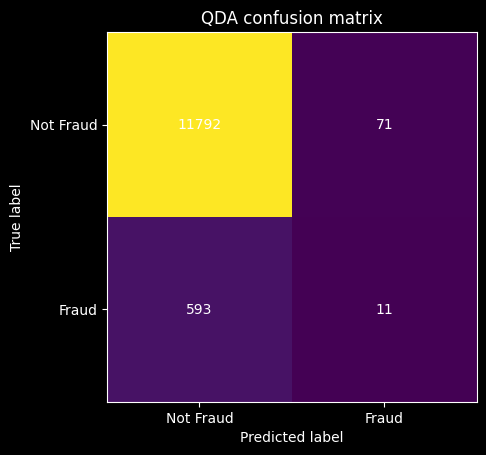

              precision    recall  f1-score   support

    No Fraud       0.95      0.99      0.97     11863
       Fraud       0.13      0.02      0.03       604

    accuracy                           0.95     12467
   macro avg       0.54      0.51      0.50     12467
weighted avg       0.91      0.95      0.93     12467



In [11]:

qda_test_pred = qda.predict(X_test)
qda_cm = confusion_matrix(y_test, qda_test_pred)
plot_confusion(qda_cm, "QDA confusion matrix")
print(classification_report(y_test, qda_test_pred, target_names=target_names))


## PCA

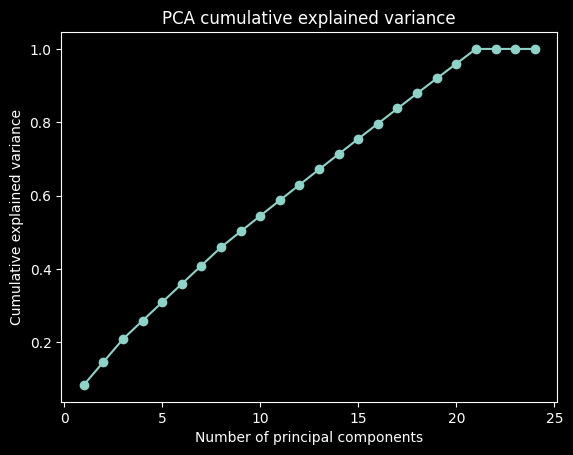

PC1 explained variance ratio: 0.0834
PC2 explained variance ratio: 0.0627
PC3 explained variance ratio: 0.0625
PC4 explained variance ratio: 0.0503
PC5 explained variance ratio: 0.0502


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
pca.fit(X_train_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(explained) + 1), cum_explained, marker="o")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA cumulative explained variance")
plt.show()

for i in range(5):
    print(f"PC{i+1} explained variance ratio: {explained[i]:.4f}")

In [13]:
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

## qda with pca

In [14]:
qda = QDAWithThreshold(threshold=.075, reg_param = .035)
#0.035, 0.075
qda.fit(X_train_pca, y_train)
    #QuadraticDiscriminantAnalysis(reg_param=.001, priors=[.5, .5]))
probs_positive_class = qda.predict_proba(X_test_pca)[:, 1]
qda, qda_results_pca = evaluate_classifier(qda, X_train_pca, X_test_pca, y_train, y_test, "QDA")
pd.DataFrame([qda_results_pca])

,model,train_accuracy,test_accuracy,roc_auc
0,QDA,0.938929,0.938798,0.531488


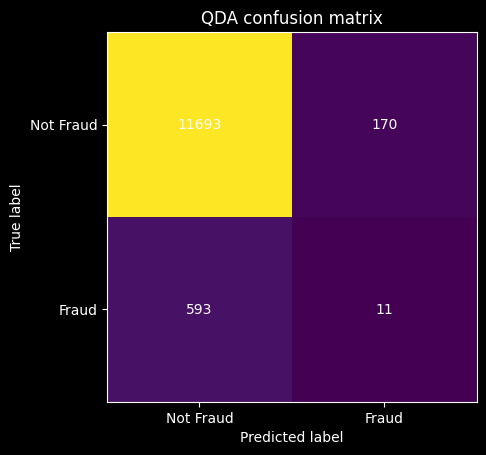

              precision    recall  f1-score   support

    No Fraud       0.95      0.99      0.97     11863
       Fraud       0.06      0.02      0.03       604

    accuracy                           0.94     12467
   macro avg       0.51      0.50      0.50     12467
weighted avg       0.91      0.94      0.92     12467



In [15]:

qda_test_pred = qda.predict(X_test_pca)
qda_cm = confusion_matrix(y_test, qda_test_pred)
plot_confusion(qda_cm, "QDA confusion matrix")
print(classification_report(y_test, qda_test_pred, target_names=target_names))